# Integrated Customer Risk Predictions

In [ ]:
# Integration Notebook: Churn + Loan Default Predictions

import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import json
import seaborn as sns

# Load saved models and preprocessing objects
# Churn model
churn_model = joblib.load("C:/AMOD/Extensive_bank/models/churn_model.pkl")
churn_scaler = joblib.load("C:/AMOD/Extensive_bank/models/scaler_churn.pkl")
with open("C:/AMOD/Extensive_bank/models/churn_features.json","r") as f:
    churn_feature_columns = json.load(f)
# Loan default model
loan_default_model = xgb.Booster()
loan_default_model.load_model("C:/AMOD/Extensive_bank/models/xgboost_loan_default.bin")
loan_default_scaler = joblib.load("C:/AMOD/Extensive_bank/models/scaler_loan_default.pkl")
with open("C:/AMOD/Extensive_bank/models/loan_default_features.json","r") as f:
    loan_default_features = json.load(f)

# Label encoders for Loan Default
le_EmploymentType = joblib.load("C:/AMOD/Extensive_bank/models/le_EmploymentType.pkl")
le_LoanPurpose = joblib.load("C:/AMOD/Extensive_bank/models/le_LoanPurpose.pkl")

# Binary mapping for Yes/No
binary_mapping = joblib.load("C:/AMOD/Extensive_bank/models/binary_mapping.pkl")

# Load new incoming data

# Raw CSV with both churn & loan features
data = pd.read_csv("C:/AMOD/Extensive_bank/data/new_data.csv")


# Churn preprocessing

# Drop ID columns and target if present
churn_drop_cols = ['RowNumber','CustomerId','Surname','Exited']
churn_data = data.drop(columns=[col for col in churn_drop_cols if col in data.columns])

# One-hot encode categorical columns
churn_data = pd.get_dummies(churn_data, columns=['Geography','Gender'], drop_first=True)

# Add missing columns (dummy alignment)
for col in churn_feature_columns:
    if col not in churn_data.columns:
        churn_data[col] = 0

# Reorder columns exactly like training
churn_data = churn_data[churn_feature_columns]

# Scale numeric features
churn_data_scaled = churn_scaler.transform(churn_data)

# Loan Default preprocessing

loan_data = data.copy()

# Drop unique ID
loan_data = loan_data.drop('LoanID', axis=1, errors='ignore')

# One-hot encode
loan_data = pd.get_dummies(loan_data, columns=['Education','MaritalStatus'], drop_first=True)

# Convert binary columns
binary_cols = ['HasMortgage','HasDependents','HasCoSigner']
for col in binary_cols:
    loan_data[col] = loan_data[col].map({'Yes':1,'No':0})

# Load encoders
le_EmploymentType = joblib.load("C:/AMOD/Extensive_bank/models/le_EmploymentType.pkl")
le_LoanPurpose = joblib.load("C:/AMOD/Extensive_bank/models/le_LoanPurpose.pkl")

# Encode categorical columns
loan_data['EmploymentType'] = le_EmploymentType.transform(loan_data['EmploymentType'])
loan_data['LoanPurpose'] = le_LoanPurpose.transform(loan_data['LoanPurpose'])

# Align features
for col in loan_default_features:
    if col not in loan_data.columns:
        loan_data[col] = 0

loan_data = loan_data[loan_default_features]

# Now scale
X_default_scaled = loan_default_scaler.transform(loan_data)

# Convert scaled features to DMatrix for XGBoost
dmatrix_default = xgb.DMatrix(X_default_scaled, feature_names=loan_default_features)

# Predictions

# Churn predictions
churn_preds_proba = churn_model.predict_proba(churn_data_scaled)[:,1]  # probability of exit
churn_preds = (churn_preds_proba >= 0.5).astype(int)  # threshold 0.5

# Loan Default predictions
loan_default_preds_proba = loan_default_model.predict(dmatrix_default)
loan_default_preds = (loan_default_preds_proba >= 0.5).astype(int)

# Combine results

results = data.copy()
results['Churn_Prediction'] = churn_preds
results['Churn_Probability'] = churn_preds_proba
results['LoanDefault_Prediction'] = loan_default_preds
results['LoanDefault_Probability'] = loan_default_preds_proba


# Save or display results

results.to_csv("C:/AMOD/Extensive_bank/data/predictions_results.csv", index=False)
print("Predictions saved to predictions_results.csv")
results.head()

Predictions saved to predictions_results.csv


,CreditScore,Age,Geography,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Churn_Prediction,Churn_Probability,LoanDefault_Prediction,LoanDefault_Probability
0,361,48,Spain,Female,4,120551.40,1,1,1,37140.99,...,Self-employed,Married,Yes,Yes,Business,Yes,1,0.615,0,0.040689
1,756,39,France,Male,0,245204.03,1,1,0,94762.09,...,Unemployed,Divorced,No,Yes,Home,Yes,0,0.465,0,0.091381
2,433,56,Spain,Male,3,244455.08,3,0,1,149300.81,...,Full-time,Married,No,No,Auto,No,1,0.855,1,0.668455
3,563,66,Spain,Female,0,47799.58,1,0,0,125006.27,...,Unemployed,Single,Yes,Yes,Home,No,1,0.740,0,0.035388
4,436,86,Germany,Female,4,127973.72,2,0,1,79770.02,...,Full-time,Married,No,No,Auto,Yes,0,0.455,0,0.025402


In [20]:

print(results[['Churn_Probability','LoanDefault_Probability']].describe())

       Churn_Probability  LoanDefault_Probability
count         100.000000               100.000000
mean            0.537400                 0.166728
std             0.291951                 0.171514
min             0.020000                 0.013295
25%             0.291250                 0.046006
50%             0.620000                 0.091819
75%             0.806250                 0.230296
max             0.940000                 0.720712


The model predictions show that customer churn risk (mean = 53.7%) is significantly higher than loan default risk (mean = 16.7%). While most customers have low default probabilities, a subset of customers exhibit very high churn probabilities (>80%), highlighting the need for proactive customer retention strategies.

<Axes: xlabel='Churn_Probability', ylabel='Count'>

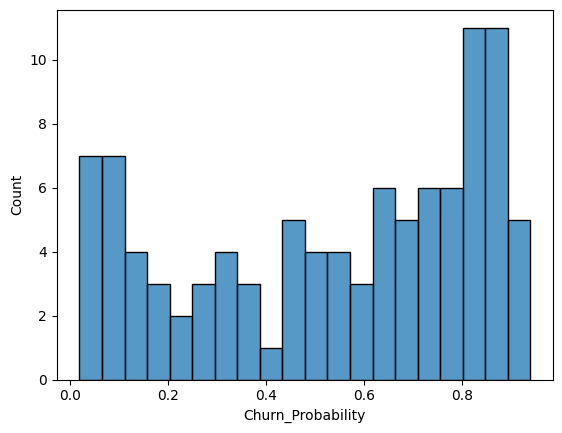

In [22]:
sns.histplot(results['Churn_Probability'], bins=20)

<Axes: xlabel='LoanDefault_Probability', ylabel='Count'>

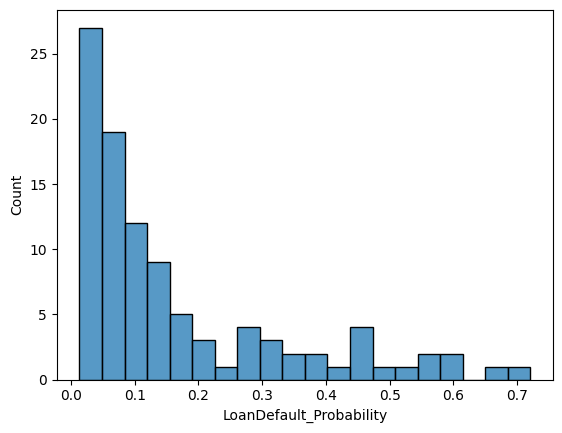

In [24]:
sns.histplot(results['LoanDefault_Probability'], bins=20)